In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:.2f}'.format

In [ ]:
qSales = pd.read_csv('qSales_2024.csv')
display(qSales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272,102450,2022-12-31,2022,3,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2022Q4,2022Q3,5280.78,A
273,102450,2023-03-31,2022,4,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q1,2022Q4,2226.88,A
274,102450,2023-06-30,2023,1,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q2,2023Q1,3190.81,A
275,102450,2023-09-30,2023,2,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q3,2023Q2,2140.04,A


In [ ]:
apple_sales = qSales.loc[qSales['tic']=='AAPL']
display(apple_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,1690,2022-12-31,2023,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2022Q4,2023Q1,117154.00,A
88,1690,2023-03-31,2023,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q1,2023Q2,94836.00,A
89,1690,2023-06-30,2023,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q2,2023Q3,81797.00,A
90,1690,2023-09-30,2023,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q3,2023Q4,89498.00,A


In [ ]:
# Step 0 is make sure your dates are recognized as dates

apple_sales['datadate'] = pd.to_datetime(apple_sales['datadate'])

/tmp/ipykernel_3399/2231144007.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apple_sales['datadate'] = pd.to_datetime(apple_sales['datadate'])


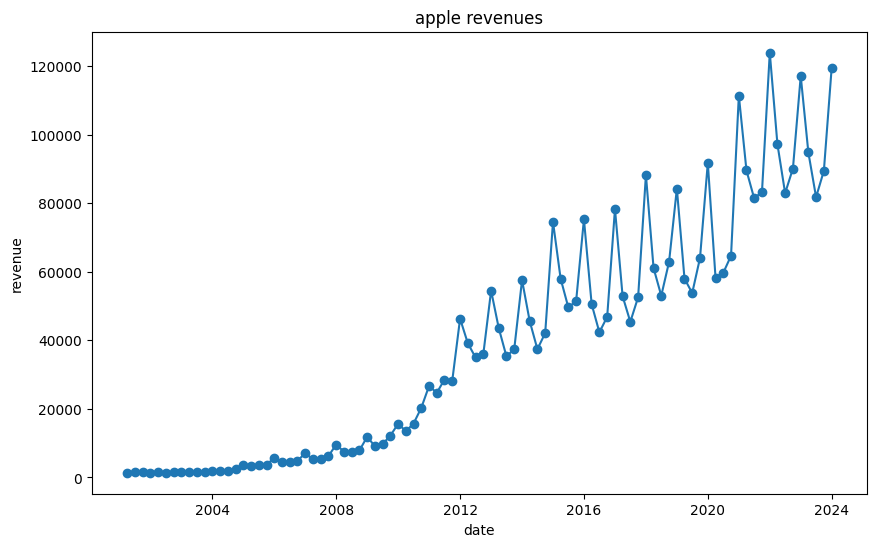

In [ ]:
# Step 1 is to vizualise the data to see what it looks like

plt.figure(figsize=(10,6))

plt.title('apple revenues')

plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(apple_sales['datadate'],apple_sales['saleq'],marker='o')

In [ ]:
# Step 2 is to create a new column called time, and it will be our independent variable
# each row of the dataset must be an equivalent time period
# For example each row is a quarter, or a day, or a year, etc.

apple_sales['time'] = range(1, len(apple_sales) + 1)

/tmp/ipykernel_3399/2875257293.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apple_sales['time'] = range(1, len(apple_sales) + 1)


In [ ]:
# How to split data into 75-25 when its not labeled
# The following code tells python to take the first 75% of rows

dt4training = apple_sales[:int(0.75*len(apple_sales))]

# The following code tells python to take everything after the first 75% of rows

dt4testing = apple_sales[int(0.75*len(apple_sales)):]

In [ ]:
x = dt4training.loc[:,'time']
x = sm.add_constant(x)

y = dt4training.loc[:,'saleq']

model1 = sm.OLS(y,x).fit()

model1.params

,0
const,-13536.82
time,1077.61


apples revenues = -13536.82 + 1077.61*time

In [ ]:
x_test = dt4testing.loc[:,'time']
x_test = sm.add_constant(x_test)

model1.predict(x_test)

,0
69,61895.57
70,62973.18
71,64050.78
72,65128.39
73,66206.00
74,67283.60
75,68361.21
76,69438.81
77,70516.42
78,71594.02


In [ ]:
# To get a range of values its 2 major steps
# First step is to use the get_prediction function from our model
# Second step is to get the summary frame of the prediction using a confidence level

prediction_results = model1.get_prediction(x_test)
prediction_results.summary_frame(alpha=0.2) # % 80 confidence interval

# Key numbers to look at are the obs_ci_lower and obs_ci_upper

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
69,61895.57,2457.90,58714.28,65076.87,48444.42,75346.72
70,62973.18,2511.13,59722.99,66223.37,49505.57,76440.79
71,64050.78,2564.70,60731.25,67370.32,50566.27,77535.30
72,65128.39,2618.61,61739.09,68517.69,51626.53,78630.25
73,66206.00,2672.82,62746.53,69665.46,52686.35,79725.64
74,67283.60,2727.32,63753.59,70813.61,53745.74,80821.47
75,68361.21,2782.09,64760.31,71962.10,54804.69,81917.73
76,69438.81,2837.11,65766.69,73110.93,55863.20,83014.43
77,70516.42,2892.38,66772.77,74260.07,56921.28,84111.56
78,71594.02,2947.88,67778.54,75409.50,57978.93,85209.12


In [ ]:
apple_sales['release_dummy_variable'] = np.where(apple_sales['fqtr']==1, 1, 0)

display(apple_sales)

/tmp/ipykernel_3399/2454217558.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apple_sales['release_dummy_variable'] = np.where(apple_sales['fqtr']==1, 1, 0)


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time,release_dummy_variable
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A,1,0
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A,2,0
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A,3,0
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A,4,1
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,1690,2022-12-31,2023,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2022Q4,2023Q1,117154.00,A,88,1
88,1690,2023-03-31,2023,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q1,2023Q2,94836.00,A,89,0
89,1690,2023-06-30,2023,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q2,2023Q3,81797.00,A,90,0
90,1690,2023-09-30,2023,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q3,2023Q4,89498.00,A,91,0


In [ ]:
apple_sales['release_dummmy_interaction'] = apple_sales['time']*apple_sales['release_dummy_variable']

display(apple_sales)

/tmp/ipykernel_3399/2120646074.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apple_sales['release_dummmy_interaction'] = apple_sales['time']*apple_sales['release_dummy_variable']


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time,release_dummy_variable,release_dummmy_interaction
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A,1,0,0
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A,2,0,0
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A,3,0,0
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A,4,1,4
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,1690,2022-12-31,2023,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2022Q4,2023Q1,117154.00,A,88,1,88
88,1690,2023-03-31,2023,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q1,2023Q2,94836.00,A,89,0,0
89,1690,2023-06-30,2023,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q2,2023Q3,81797.00,A,90,0,0
90,1690,2023-09-30,2023,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2023Q3,2023Q4,89498.00,A,91,0,0


In [ ]:
dt4training = apple_sales[:int(0.75*len(apple_sales)):]

dt4testing = apple_sales[:int(0.75*len(apple_sales)):]

In [ ]:
x = dt4training.loc[:,['time', 'release_dummy_variable', 'release_dummmy_interaction']]

x = sm.add_constant(x)

y = dt4training.loc[:,'saleq']
model_dummy = sm.OLS(y,x).fit()

model_dummy.params


,0
const,-11044.75
time,933.21
release_dummy_variable,-10422.13
release_dummmy_interaction,578.33


# apple revenue = -11,044 + 033*time + (-10,422)*release_dummy + 578*(time*release_dummy)

time*release_dummy = release_dummy_interaction


In [ ]:
x_test = dt4testing.loc[:,['time', 'release_dummy_variable', 'release_dummmy_interaction']]
x_test = sm.add_constant(x_test)

model_dummy.get_prediction(x_test).summary_frame(alpha=0.2)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,-10111.54,2084.80,-12810.75,-7412.32,-20414.56,191.48
1,-9178.33,2039.23,-11818.54,-6538.12,-19466.04,1109.39
2,-8245.12,1994.03,-10826.81,-5663.42,-18517.97,2027.74
3,-15420.73,3566.67,-20038.53,-10802.92,-26383.87,-4457.58
4,-6378.69,1904.88,-8844.97,-3912.42,-16623.15,3865.76
...,...,...,...,...,...,...
64,49613.95,1933.84,47110.19,52117.71,39360.40,59867.49
65,50547.16,1978.48,47985.60,53108.72,40279.34,60814.97
66,51480.37,2023.54,48860.47,54100.27,41197.85,61762.89
67,81317.78,3566.67,76699.98,85935.59,70354.64,92280.93
